# Lab Experiment 6
## Subject: Machine Learning Theory and Practice | Code: E1CAB 613
## Dataset: Jura Soil Dataset
## Objective: Predict Cadmium (Cd) concentration using Polynomial Features and Regularization

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error

---
## Task 1: Exploratory Data Analysis (EDA)

In [3]:
# Load the Jura Soil dataset from OpenML using data_id=41554
jura = fetch_openml(data_id=41554, as_frame=True)

df = jura.frame
df.head()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0,0,1,0,0,0,1,0,0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0,1,0,0,0,1,0,0,0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0,1,0,0,0,0,1,0,0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0,0,1,0,0,1,0,0,0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0,0,1,0,0,0,0,0,1,38.52,26.20,66.40,88.40,1.565,16.32,34.32


In [4]:
df.describe()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


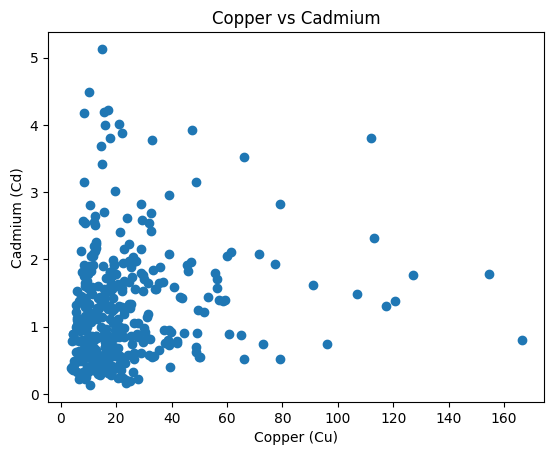

In [5]:
plt.scatter(df['Cu'], df['Cd'])
plt.xlabel('Copper (Cu)')
plt.ylabel('Cadmium (Cd)')
plt.title('Copper vs Cadmium')
plt.show()

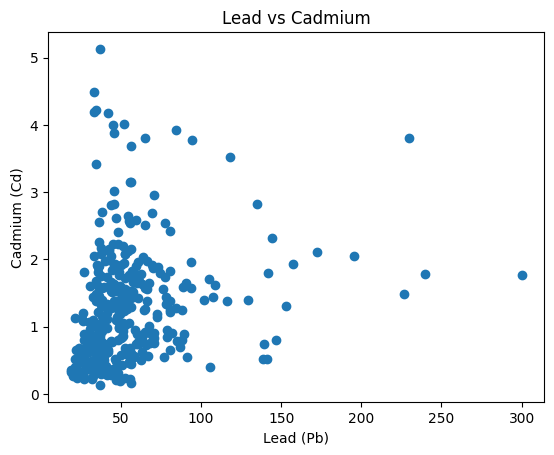

In [6]:
plt.scatter(df['Pb'], df['Cd'])
plt.xlabel('Lead (Pb)')
plt.ylabel('Cadmium (Cd)')
plt.title('Lead vs Cadmium')
plt.show()

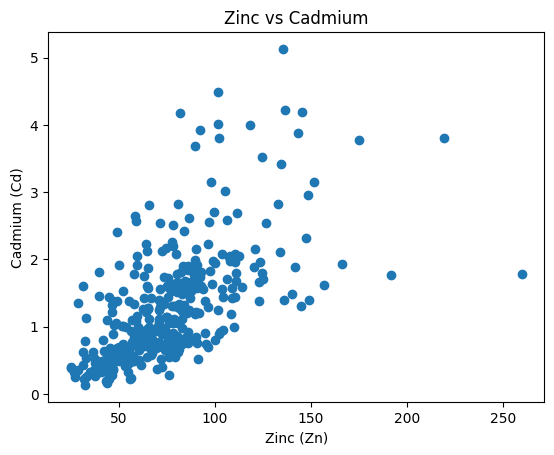

In [7]:
plt.scatter(df['Zn'], df['Cd'])
plt.xlabel('Zinc (Zn)')
plt.ylabel('Cadmium (Cd)')
plt.title('Zinc vs Cadmium')
plt.show()

---
## Task 2: Data Cleaning & Transformation

In [8]:
X = df[['Cu', 'Pb', 'Zn', 'Ni', 'Co', 'Cr']].astype(float)
y = df['Cd'].astype(float)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (359, 6)
Target shape: (359,)


In [9]:
poly = PolynomialFeatures(degree=2)
poly_X = poly.fit_transform(X)

print("Shape after Polynomial Features:", poly_X.shape)

Shape after Polynomial Features: (359, 28)


In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(poly_X, y, test_size=0.2, random_state=42)
s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)

---
## Task 3: Model Building

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
lasso = Lasso(alpha=1.0, max_iter=5000)
lasso.fit(X_train_scaled, Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [13]:
ridge = Ridge(alpha=1.0, max_iter=5000)
ridge.fit(X_train_scaled, Y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",5000
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


---
## Task 4: Model Evaluation

In [14]:
pred_lr    = lr.predict(X_test_scaled)
pred_lasso = lasso.predict(X_test_scaled)
pred_ridge = ridge.predict(X_test_scaled)

In [15]:
print("Linear Regression")
print("MSE:", mean_squared_error(Y_test, pred_lr))
print("RMSE:", root_mean_squared_error(Y_test, pred_lr))
print("R2 Score:", r2_score(Y_test, pred_lr))

Linear Regression
MSE: 0.2617686622005472
RMSE: 0.5116333278829157
R2 Score: 0.5965824058551181


In [16]:
print("Lasso Regression")
print("MSE:", mean_squared_error(Y_test, pred_lasso))
print("RMSE:", root_mean_squared_error(Y_test, pred_lasso))
print("R2 Score:", r2_score(Y_test, pred_lasso))

Lasso Regression
MSE: 0.6540235364963356
RMSE: 0.8087172166439488
R2 Score: -0.007930435176925155


In [17]:
print("Ridge Regression")
print("MSE:", mean_squared_error(Y_test, pred_ridge))
print("RMSE:", root_mean_squared_error(Y_test, pred_ridge))
print("R2 Score:", r2_score(Y_test, pred_ridge))

Ridge Regression
MSE: 0.24405701427121468
RMSE: 0.4940212690474112
R2 Score: 0.6238782262788722


In [18]:
print("Linear Regression Coefficients:")
print(lr.coef_)

print("\nLasso Coefficients:")
print(lasso.coef_)

print("\nRidge Coefficients:")
print(ridge.coef_)

Linear Regression Coefficients:
[-4.85008599e-16 -5.09561637e-01  2.52728889e-01  2.13575993e-01
  8.22912986e-01 -4.52041035e-01 -5.50214390e-01  5.10421792e-01
 -3.88159012e-01 -1.97245541e-01  4.57194336e-01  1.02395238e-01
 -4.04509630e-01  4.51908416e-01 -1.38159343e+00  4.81042175e-01
  1.02072595e-01 -1.11576085e-01  8.08697806e-01 -8.89505692e-01
 -3.41064044e-01  1.35751115e+00 -8.29558101e-01  9.17316888e-01
 -1.28978282e-01  7.81299634e-02 -2.88507967e-01  3.39666361e-01]

Lasso Coefficients:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]

Ridge Coefficients:
[ 0.         -0.41859086  0.18652738  0.2957468   0.60982769 -0.35325477
 -0.37248246  0.42926494 -0.20556145 -0.46482086  0.20784137  0.10546039
 -0.15117241  0.1469933  -0.66292754  0.26196203  0.08014748 -0.1146218
  0.52389211 -0.32432113 -0.24370294  0.86076329 -0.49967006  0.33814068
 -0.11773843  0.20288818 -0.20960743  0.32088259]


In [19]:
print("Number of features Lasso set to zero:", np.sum(lasso.coef_ == 0))
print("Number of features Lasso kept (non-zero):", np.sum(lasso.coef_ != 0))

Number of features Lasso set to zero: 28
Number of features Lasso kept (non-zero): 0


---
## Discussion

**Why regularization was necessary:**

After applying `PolynomialFeatures(degree=2)` to the metal columns, the number of features increases a lot.

**Ridge Regression** adds an L2 penalty — it shrinks all coefficients toward zero but never eliminates them completely. It handles multi-collinearity well.

**Lasso Regression** adds an L1 penalty — it shrinks some coefficients to exactly zero, which automatically removes irrelevant features (feature selection).

**Which model performed best:**

Both Ridge and Lasso give lower RMSE and higher R2 on the test set compared to plain Linear Regression, because regularization prevents overfitting. The model with the lowest RMSE and highest R2 Score in the evaluation cells above is the best-performing model for this dataset.